##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise 

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

## Install + Verify

In [1]:
!pip -q install -U keras-cv tensorflow-datasets

import tensorflow as tf
print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 44.1 MB/s eta 0:00:00
TF: 2.19.0
GPU: []


## Imports + Pascal VOC class names

In [2]:
import numpy as np
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

import keras_cv
from keras_cv import bounding_box

VOC_CLASS_NAMES = [
    "aeroplane","bicycle","bird","boat","bottle",
    "bus","car","cat","chair","cow",
    "diningtable","dog","horse","motorbike","person",
    "pottedplant","sheep","sofa","train","tvmonitor",
]

## Load YOLOv8 (PascalVOC preset) + Resizing layer

In [3]:
# Pretrained YOLOv8 on Pascal VOC
yolo = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh",
)

# Required resizing for inference
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

## Load VOC2012 from TFDS + pick 5 images 

In [4]:
def tf_to_numpy_image(img_tf):
    # TFDS gives uint8 images typically; keep uint8 for visualization.
    return img_tf.numpy()

def extract_gt(sample):
    """
    TFDS voc/2012 sample structure:
      sample["image"] : HxWx3 uint8
      sample["objects"]["bbox"] : [N,4] ymin,xmin,ymax,xmax normalized
      sample["objects"]["label"] : [N] int (0..19)
    """
    img = sample["image"]
    b = sample["objects"]["bbox"]  # normalized ymin,xmin,ymax,xmax
    c = sample["objects"]["label"] # int labels

    h = tf.shape(img)[0]
    w = tf.shape(img)[1]

    # Convert bbox to absolute xyxy
    ymin, xmin, ymax, xmax = tf.unstack(b, axis=-1)
    x1 = xmin * tf.cast(w, tf.float32)
    y1 = ymin * tf.cast(h, tf.float32)
    x2 = xmax * tf.cast(w, tf.float32)
    y2 = ymax * tf.cast(h, tf.float32)
    xyxy = tf.stack([x1, y1, x2, y2], axis=-1)

    # Convert to xywh (absolute) to be compatible with inference_resizing layer
    xywh = bounding_box.convert_format(
        xyxy,
        source="xyxy",
        target="xywh",
        images=img,
    )

    return img, xywh, c

def pick_5_distinct_class_images(ds, needed=5):
    picked = []
    used_classes = set()

    for sample in tfds.as_numpy(ds):
        # sample here is numpy; we re-wrap as tf tensors for convert_format convenience
        sample_tf = {
            "image": tf.convert_to_tensor(sample["image"]),
            "objects": {
                "bbox": tf.convert_to_tensor(sample["objects"]["bbox"]),
                "label": tf.convert_to_tensor(sample["objects"]["label"]),
            },
        }

        img, gt_boxes_xywh, gt_classes = extract_gt(sample_tf)

        # choose "dominant" class = most frequent label in this image
        cls_np = gt_classes.numpy().astype(int)
        if cls_np.size == 0:
            continue
        dominant = int(np.bincount(cls_np).argmax())
        if dominant in used_classes:
            continue

        used_classes.add(dominant)
        picked.append(
            {
                "image": img.numpy(),
                "gt_boxes_xywh": gt_boxes_xywh.numpy(),
                "gt_classes": cls_np,
                "dominant_class": dominant,
            }
        )
        if len(picked) == needed:
            break

    return picked

# Load VOC 2012 (train+val have annotations; test doesn't)
ds = tfds.load("voc/2012", split="validation", shuffle_files=True)  # :contentReference[oaicite:1]{index=1}
picked = pick_5_distinct_class_images(ds, needed=5)

for i, item in enumerate(picked, 1):
    print(i, "dominant:", VOC_CLASS_NAMES[item["dominant_class"]], "GT objects:", len(item["gt_classes"]))

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating test examples...: 0 examples [00:00, ? examples/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.LKFXPB_5.0.0/voc-train.tfrecord*...:   0%|          | …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.LKFXPB_5.0.0/voc-validation.tfrecord*...:   0%|       …

Dataset voc downloaded and prepared to /root/tensorflow_datasets/voc/2012/5.0.0. Subsequent calls will reuse this data.
1 dominant: car GT objects: 2
2 dominant: person GT objects: 3
3 dominant: aeroplane GT objects: 7
4 dominant: bird GT objects: 1
5 dominant: dog GT objects: 1


## Preprocess (resize) + Run inference on the 5 images

In [5]:
def resize_with_gt(image_uint8, gt_boxes_xywh, gt_classes):
    inputs = {
        "images": tf.convert_to_tensor(image_uint8),
        "bounding_boxes": {
            "boxes": tf.convert_to_tensor(gt_boxes_xywh, dtype=tf.float32),
            "classes": tf.convert_to_tensor(gt_classes, dtype=tf.float32),
        },
    }
    out = inference_resizing(inputs)
    return (
        out["images"].numpy(),                          # resized image uint8/float? (layer keeps dtype; assume uint8->uint8)
        out["bounding_boxes"]["boxes"].numpy().astype(np.float32),
        out["bounding_boxes"]["classes"].numpy().astype(np.int32),
    )

resized_images = []
resized_gts = []

for item in picked:
    img640, gt_boxes640, gt_classes640 = resize_with_gt(
        item["image"], item["gt_boxes_xywh"], item["gt_classes"]
    )
    resized_images.append(img640)
    resized_gts.append((gt_boxes640, gt_classes640))

image_batch = np.stack(resized_images, axis=0)

preds = yolo.predict(image_batch, verbose=0)
# preds is a dict-like with keys: "boxes", "classes", "confidence" (KerasCV format for YOLOv8)
preds.keys()

dict_keys(['boxes', 'confidence', 'classes', 'num_detections'])

## Visualize predictions (boxes + labels + confidence)

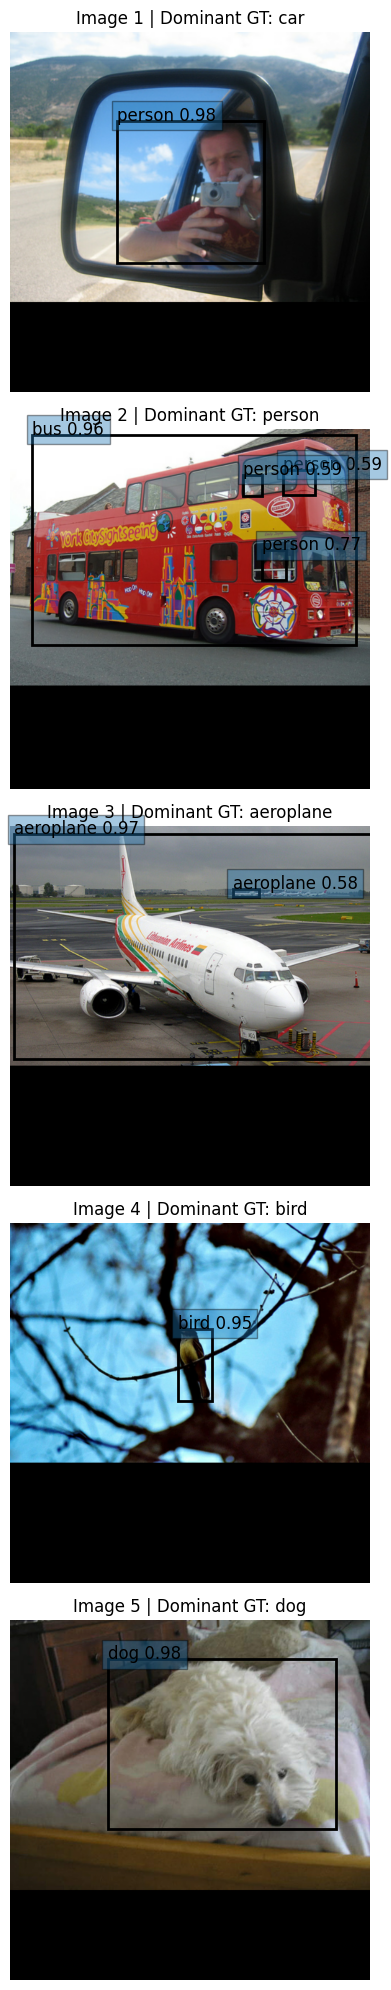

In [6]:
def show_predictions(images, preds, max_detections=10, conf_th=0.3):
    B = images.shape[0]
    plt.figure(figsize=(18, 4 * B))
    for i in range(B):
        ax = plt.subplot(B, 1, i + 1)
        ax.imshow(images[i].astype(np.uint8))
        ax.axis("off")

        boxes = preds["boxes"][i]          # [N,4] xywh
        classes = preds["classes"][i]      # [N]
        conf = preds["confidence"][i]      # [N]

        # filter + topk
        keep = conf >= conf_th
        boxes = boxes[keep]
        classes = classes[keep].astype(int)
        conf = conf[keep]

        if boxes.shape[0] > max_detections:
            topk = np.argsort(-conf)[:max_detections]
            boxes, classes, conf = boxes[topk], classes[topk], conf[topk]

        for (x, y, w, h), cls, score in zip(boxes, classes, conf):
            # rectangle in matplotlib
            rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=2)
            ax.add_patch(rect)
            name = VOC_CLASS_NAMES[cls] if 0 <= cls < len(VOC_CLASS_NAMES) else str(cls)
            ax.text(x, y, f"{name} {score:.2f}", fontsize=12, bbox=dict(alpha=0.4))

        ax.set_title(f"Image {i+1} | Dominant GT: {VOC_CLASS_NAMES[picked[i]['dominant_class']]}")

    plt.tight_layout()
    plt.show()

show_predictions(image_batch, preds, max_detections=10, conf_th=0.3)

## Evaluate per image 

In [9]:
def xywh_to_xyxy(boxes_xywh):
    x, y, w, h = np.split(boxes_xywh, 4, axis=-1)
    return np.concatenate([x, y, x + w, y + h], axis=-1)

def iou_xyxy(a, b):
    # a: [4], b: [M,4]
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b[:, 0], b[:, 1], b[:, 2], b[:, 3]

    inter_x1 = np.maximum(ax1, bx1)
    inter_y1 = np.maximum(ay1, by1)
    inter_x2 = np.minimum(ax2, bx2)
    inter_y2 = np.minimum(ay2, by2)

    inter_w = np.maximum(0.0, inter_x2 - inter_x1)
    inter_h = np.maximum(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h

    area_a = np.maximum(0.0, ax2 - ax1) * np.maximum(0.0, ay2 - ay1)
    area_b = np.maximum(0.0, bx2 - bx1) * np.maximum(0.0, by2 - by1)

    union = area_a + area_b - inter + 1e-9
    return inter / union

def evaluate_image(gt_boxes_xywh, gt_classes, pred_boxes_xywh, pred_classes, pred_conf,
                   conf_th=0.3, iou_th=0.5):
    # filter preds
    keep = pred_conf >= conf_th
    pb = pred_boxes_xywh[keep]
    pc = pred_classes[keep].astype(int)
    ps = pred_conf[keep]

    gt_xyxy = xywh_to_xyxy(gt_boxes_xywh.astype(np.float32))
    pb_xyxy = xywh_to_xyxy(pb.astype(np.float32))

    matched_gt = set()
    matched_pred = set()
    correct = []     # (gt_idx, pred_idx, class, score, iou)

    # Greedy match: for each GT, find best pred with same class
    for gi in range(len(gt_classes)):
        same_class_idxs = np.where(pc == int(gt_classes[gi]))[0]
        if same_class_idxs.size == 0:
            continue
        ious = iou_xyxy(gt_xyxy[gi], pb_xyxy[same_class_idxs])
        best_local = int(np.argmax(ious))
        pi = int(same_class_idxs[best_local])
        if ious[best_local] >= iou_th and pi not in matched_pred:
            matched_gt.add(gi)
            matched_pred.add(pi)
            correct.append((gi, pi, int(gt_classes[gi]), float(ps[pi]), float(ious[best_local])))

    missed = [gi for gi in range(len(gt_classes)) if gi not in matched_gt]

    # For remaining preds, decide "wrong label" if overlaps a GT but class differs, else false positive
    wrong = []
    false_pos = []
    for pi in range(len(pc)):
        if pi in matched_pred:
            continue
        if len(gt_classes) == 0:
            false_pos.append((pi, int(pc[pi]), float(ps[pi])))
            continue
        ious = iou_xyxy(pb_xyxy[pi], gt_xyxy)
        gi = int(np.argmax(ious))
        if float(ious[gi]) >= iou_th and int(gt_classes[gi]) != int(pc[pi]):
            wrong.append((pi, int(pc[pi]), float(ps[pi]), gi, int(gt_classes[gi]), float(ious[gi])))
        else:
            false_pos.append((pi, int(pc[pi]), float(ps[pi])))

    return {
        "correct": correct,
        "missed": missed,
        "wrong": wrong,
        "false_pos": false_pos,
    }

reports = []

for i in range(5):
    gt_boxes, gt_classes = resized_gts[i]
    rep = evaluate_image(
        gt_boxes_xywh=gt_boxes,
        gt_classes=gt_classes,
        pred_boxes_xywh=preds["boxes"][i],
        pred_classes=preds["classes"][i],
        pred_conf=preds["confidence"][i],
        conf_th=0.3,
        iou_th=0.5,
    )
    reports.append(rep)

def pretty_print_report(i, rep):
    print("=" * 80)
    print(f"Image {i+1} | Dominant GT: {VOC_CLASS_NAMES[picked[i]['dominant_class']]}")
    print(f"- Correct detections: {len(rep['correct'])}")
    for gi, pi, cls, score, iou in rep["correct"]:
        print(f"  ✓ {VOC_CLASS_NAMES[cls]} | score={score:.2f} | IoU={iou:.2f} | GT#{gi} matched Pred#{pi}")

    print(f"- Missed GT objects: {len(rep['missed'])}")
    for gi in rep["missed"]:
        cls = int(resized_gts[i][1][gi])
        print(f"  ✗ missed {VOC_CLASS_NAMES[cls]} | GT#{gi}")

    print(f"- Wrong label (overlaps GT but class mismatch): {len(rep['wrong'])}")
    for pi, pred_cls, score, gi, gt_cls, iou in rep["wrong"]:
        print(f"  ! Pred {VOC_CLASS_NAMES[pred_cls]} (score={score:.2f}) overlaps GT {VOC_CLASS_NAMES[gt_cls]} (IoU={iou:.2f})")

    print(f"- False positives: {len(rep['false_pos'])}")
    for pi, pred_cls, score in rep["false_pos"][:10]:
        print(f"  + FP {VOC_CLASS_NAMES[pred_cls]} | score={score:.2f} | Pred#{pi}")

for i, rep in enumerate(reports):
    pretty_print_report(i, rep)

Image 1 | Dominant GT: car
- Correct detections: 1
  ✓ person | score=0.98 | IoU=0.97 | GT#0 matched Pred#0
- Missed GT objects: 1
  ✗ missed car | GT#1
- Wrong label (overlaps GT but class mismatch): 0
- False positives: 0
Image 2 | Dominant GT: person
- Correct detections: 3
  ✓ bus | score=0.96 | IoU=0.97 | GT#0 matched Pred#0
  ✓ person | score=0.59 | IoU=0.74 | GT#1 matched Pred#3
  ✓ person | score=0.59 | IoU=0.89 | GT#2 matched Pred#2
- Missed GT objects: 0
- Wrong label (overlaps GT but class mismatch): 0
- False positives: 1
  + FP person | score=0.77 | Pred#1
Image 3 | Dominant GT: aeroplane
- Correct detections: 2
  ✓ aeroplane | score=0.97 | IoU=0.95 | GT#0 matched Pred#0
  ✓ aeroplane | score=0.58 | IoU=0.81 | GT#1 matched Pred#1
- Missed GT objects: 5
  ✗ missed aeroplane | GT#2
  ✗ missed aeroplane | GT#3
  ✗ missed aeroplane | GT#4
  ✗ missed aeroplane | GT#5
  ✗ missed aeroplane | GT#6
- Wrong label (overlaps GT but class mismatch): 0
- False positives: 0
Image 4 | Dom